In [5]:
#enable autoreload

%load_ext autoreload
%autoreload all

#common jupyter functions
from IPython.display import display, clear_output
from tqdm.notebook import tqdm

#configure matplotlib
%matplotlib widget
import matplotlib.pyplot as plt
plt.ioff()

import sys, os.path
importPath = os.path.abspath('../../common')
if not importPath in sys.path:
    sys.path.append(importPath)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
#define paths
evalResultsPath = "./data/eval-on-words.parquet"

corpusPath = "../data/preproc/ktu/corpus_AICP_FIMI_2026-01-24.ranged.json"

In [7]:
#load data
import polars as pl
dfEval = pl.read_parquet(evalResultsPath)
display(dfEval.head(5))

#get label distribution from the corpus
from corpus.chunkedCorpus import ChunkedCorpus
corpus = ChunkedCorpus.loadFromJson(corpusPath)
labelGrps = corpus.labelGrps
print(f"Label groups: '{labelGrps}'")

#find neutral labels
neutralLblIdxs = []
offset = 0
for grpSize in labelGrps:
    neutralLblIdxs.append(offset)
    offset += grpSize
print(f"Neutral labels are: '{neutralLblIdxs}")

model_version,sample_idx,expected_labels,found_labels,confidence
i64,i64,"array[f32, 15]","array[f32, 15]","array[f32, 15]"
0,0,"[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]","[0.184485, 0.000817, … 0.000018]"
0,1,"[1.0, 0.0, … 0.0]","[1.0, 0.0, … 0.0]","[0.993208, 0.000001, … 0.000047]"
0,2,"[1.0, 0.0, … 0.0]","[1.0, 0.0, … 0.0]","[0.994509, 0.000015, … 0.000359]"
0,3,"[1.0, 0.0, … 0.0]","[1.0, 0.0, … 0.0]","[0.908506, 5.6170e-7, … 0.000523]"
0,4,"[0.0, 0.0, … 0.0]","[1.0, 0.0, … 0.0]","[0.979466, 4.0601e-7, … 0.000027]"


Label groups: '[15]'
Neutral labels are: '[0]


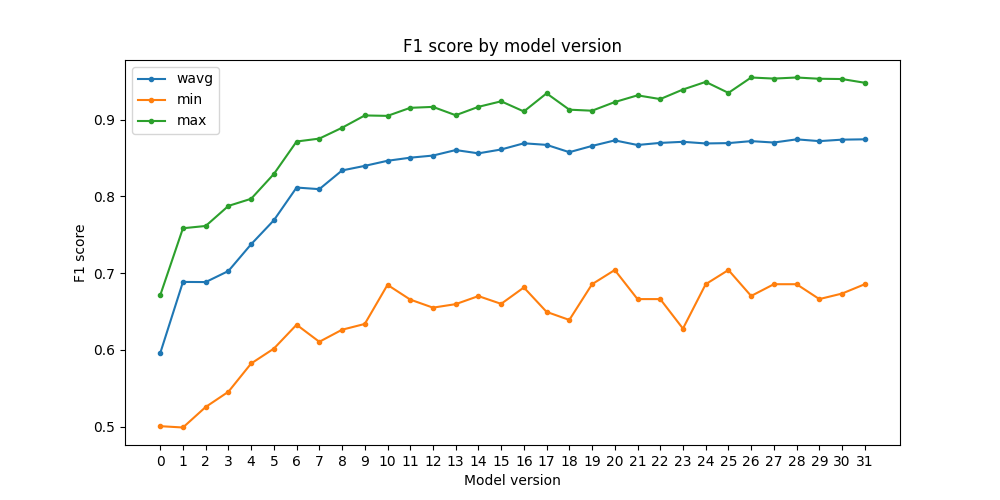

In [8]:
#f1 score for each model version

import metrics.scores as scores
import numpy as np
import matplotlib.pyplot as plt

#compute f1 score for each model version
modelVersions = dfEval.select(pl.col("model_version").unique().sort()).to_series().to_list()
numLbls = len(dfEval.select(pl.col("expected_labels")).to_series()[0])

avgModelScores = []
minModelScores = []
maxModelScores = []

for modelVersion in modelVersions:
	expected = dfEval.filter(pl.col("model_version")==modelVersion).select(pl.col("expected_labels")).to_series().to_list()
	predicted = dfEval.filter(pl.col("model_version")==modelVersion).select(pl.col("found_labels")).to_series().to_list()
	
	modelLblScores = []
	lblCnts = []
	for lblIdx in range(numLbls):
		lblExpected = scores.extractLabelPreds(expected, lblIdx)
		lblPredicted = scores.extractLabelPreds(predicted, lblIdx)

		score = scores.f1score(lblExpected, lblPredicted)

		modelLblScores.append(score)
		lblCnts.append(int(sum(lblExpected)))
	
	modelLblScores = np.array(modelLblScores)
	lblCnts = np.array(lblCnts)

	avgModelScores.append(np.average(modelLblScores, weights=lblCnts))
	minModelScores.append(modelLblScores.min())
	maxModelScores.append(modelLblScores.max())

#plot
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(np.arange(len(modelVersions)), avgModelScores, label="wavg", marker=".")
ax.plot(np.arange(len(modelVersions)), minModelScores, label="min", marker=".")
ax.plot(np.arange(len(modelVersions)), maxModelScores, label="max", marker=".")

ax.set_xticks(np.arange(len(modelVersions)))
ax.set_xticklabels(modelVersions)

ax.legend()
ax.set_ylabel("F1 score")
ax.set_xlabel("Model version")
ax.set_title("F1 score by model version")

fig.show()

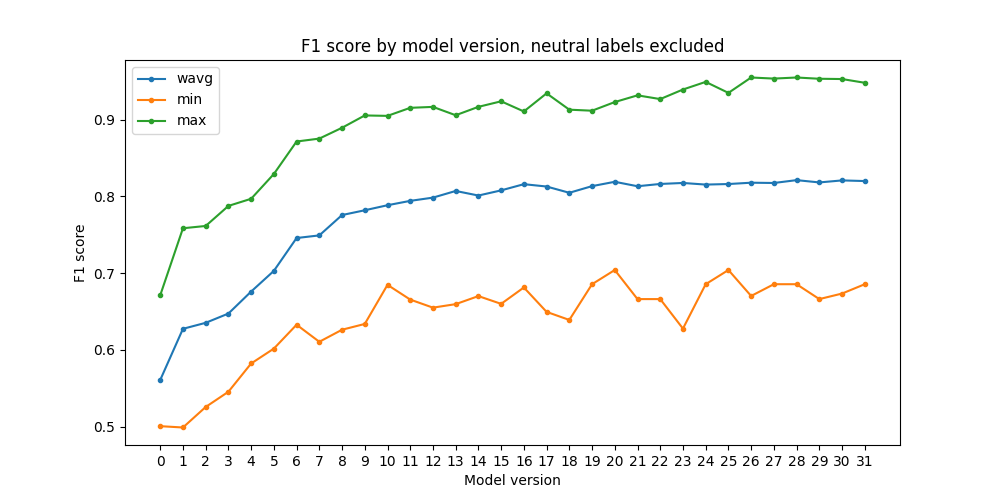

In [9]:
#f1 score for each model version, but neutral labels are excluded

import metrics.scores as scores
import numpy as np
import matplotlib.pyplot as plt

#compute f1 score for each model version
modelVersions = dfEval.select(pl.col("model_version").unique().sort()).to_series().to_list()
numLbls = len(dfEval.select(pl.col("expected_labels")).to_series()[0])

avgModelScores = []
minModelScores = []
maxModelScores = []

for modelVersion in modelVersions:
	expected = dfEval.filter(pl.col("model_version")==modelVersion).select(pl.col("expected_labels")).to_series().to_list()
	predicted = dfEval.filter(pl.col("model_version")==modelVersion).select(pl.col("found_labels")).to_series().to_list()
	
	modelLblScores = []
	lblCnts = []
	for lblIdx in range(numLbls):
		if lblIdx not in neutralLblIdxs:
			lblExpected = scores.extractLabelPreds(expected, lblIdx)
			lblPredicted = scores.extractLabelPreds(predicted, lblIdx)

			score = scores.f1score(lblExpected, lblPredicted)

			modelLblScores.append(score)
			lblCnts.append(int(sum(lblExpected)))
	
	modelLblScores = np.array(modelLblScores)
	lblCnts = np.array(lblCnts)

	avgModelScores.append(np.average(modelLblScores, weights=lblCnts))
	minModelScores.append(modelLblScores.min())
	maxModelScores.append(modelLblScores.max())

#plot
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(np.arange(len(modelVersions)), avgModelScores, label="wavg", marker=".")
ax.plot(np.arange(len(modelVersions)), minModelScores, label="min", marker=".")
ax.plot(np.arange(len(modelVersions)), maxModelScores, label="max", marker=".")

ax.set_xticks(np.arange(len(modelVersions)))
ax.set_xticklabels(modelVersions)

ax.legend()
ax.set_ylabel("F1 score")
ax.set_xlabel("Model version")
ax.set_title("F1 score by model version, neutral labels excluded")

fig.show()

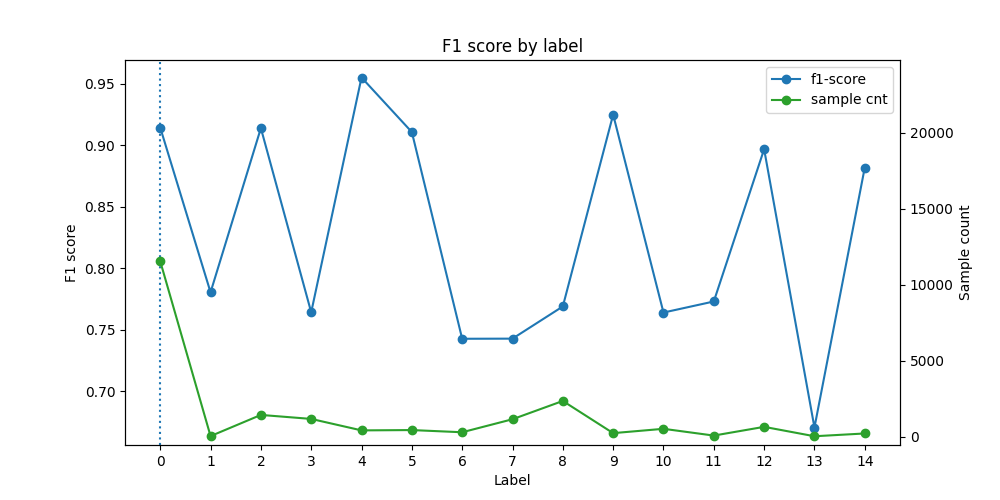

In [11]:
#plot F1 scores for each label of a chosen model version

modelVersion = 26

import metrics.scores as scores
import numpy as np
import matplotlib.pyplot as plt

#compute f1 score for each label
numLbls = len(dfEval.select(pl.col("expected_labels")).to_series()[0])

lblScores = []
lblCnts = []

expected = dfEval.filter(pl.col("model_version")==modelVersion).select(pl.col("expected_labels")).to_series().to_list()
predicted = dfEval.filter(pl.col("model_version")==modelVersion).select(pl.col("found_labels")).to_series().to_list()
	
for lblIdx in range(numLbls):    
    lblExpected = scores.extractLabelPreds(expected, lblIdx)
    lblPredicted = scores.extractLabelPreds(predicted, lblIdx)

    score = scores.f1score(lblExpected, lblPredicted)

    lblScores.append(score)
    lblCnts.append(int(sum(lblExpected)))

#plot
fig, ax = plt.subplots(figsize=(10, 5))

#...f1 scores with neutral labels marked
ax.plot(range(numLbls), lblScores, marker='o', linestyle="-", label="f1-score")
for lblIdx in neutralLblIdxs:
    ax.axvline(lblIdx, linestyle=":")

#...label counts
ax1 = ax.twinx()

ax1.plot(range(numLbls), lblCnts, marker='o', linestyle="-", label="sample cnt", color="C2")

#...make secondary plot smaller, to not obstruct primary one
l, h = ax1.get_ylim()
ax1.set_ylim(l, l + (h-l) * 2)

#...plot metadata
ax.set_xticks(np.arange(numLbls))
ax.set_xticklabels(np.arange(numLbls))

ax.set_ylabel("F1 score")
ax.set_xlabel("Label")
ax1.set_ylabel("Sample count")
ax.set_title("F1 score by label")

lines, labels = ax.get_legend_handles_labels()
lines1, labels1 = ax1.get_legend_handles_labels()
ax.legend(lines + lines1, labels + labels1)

fig.show()